# Monte Carlo Kernel Benchmarking

This notebook performs a comprehensive performance evaluation of different OpenCL kernels implemented for the Monte Carlo simulation. We compare the **Standard 1D**, **Ping-Pong**, and the **Vectorized** approaches across various metrics, including execution time, memory bandwidth, VRAM footprint, and throughput.

**Bandwidth metric.** The reported *Effective Bandwidth* is computed as `(n_runs × n_cells × 4 + n_wg × 4) / time` (canonical effective-bandwidth convention: every global-memory load/store instruction is counted at face value, regardless of cache hits). Because `p_vec` (~600 KB for this habitat) fits in the GPU's L2 cache, the measured values can exceed the device's DRAM peak (the 4050 is ~190-270 GB/s) — in that regime the metric reflects cache→SM throughput, not VRAM→SM.

## Environment Setup

Loading environment variables and importing necessary modules for the simulation and data analysis.

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv

from pyroclast import (
    FileMapRepository,
    HabitatCriteria,
    PyOpenCLAdapter,
    PyOpenCLMonteCarloAdapter,
    PyOpenCLMonteCarloPingPongAdapter,
    PyOpenCLMonteCarloVectorizedAdapter,
    PyOpenCLMonteCarloVectorizedPingPongAdapter,
)
from pyroclast.domain.models import GridTopology, MonteCarloConfig
from pyroclast.services import run_preprocessing_batch

load_dotenv()
data_path = os.getenv("DATA_PATH", "data").strip('"\'')
cache_dir = Path(os.getenv("CACHE_DIR", str(Path(data_path) / "cache")).strip('"\''))

## Data Preparation

Running the preprocessing pipeline to obtain the compacted habitat data required for the Monte Carlo simulation.

In [2]:
repo = FileMapRepository(data_path)
preprocess_adapter = PyOpenCLAdapter()
compacted = run_preprocessing_batch(
    repo=repo,
    compute=preprocess_adapter,
    criteria=HabitatCriteria(),
    cache_dir=cache_dir,
)
target_habitat = compacted[0]
print(f"Selected Habitat: {target_habitat.habitat_code} ({target_habitat.n_cells} cells)")

Selected Habitat: 4090 (153989 cells)


pci id for fd 86: 10de:28e1, driver (null)
pci id for fd 87: 10de:28e1, driver (null)


## Phase 1: Single-Shot Performance Analysis

Executing a single benchmark run with a high number of simulations (1,000,000) for all kernels to collect detailed performance metrics including VRAM footprint and speedup.

In [3]:
MC_RUNS = 1_000_000
THRESHOLD = 0.005
SEED = 42
N_BATCHES = 10

kernels_to_bench = [
    {"name": "Standard",       "adapter": PyOpenCLMonteCarloAdapter(profiling=True)},
    {"name": "Ping-Pong",      "adapter": PyOpenCLMonteCarloPingPongAdapter(profiling=True)},
    {"name": "Vec-w2",        "adapter": PyOpenCLMonteCarloVectorizedAdapter(profiling=True, vec_width=2)},
    {"name": "VecPP-w2",      "adapter": PyOpenCLMonteCarloVectorizedPingPongAdapter(profiling=True, vec_width=2)},
]


def _canonical_topology(adapter, n_wg_target: int) -> GridTopology:
    return GridTopology(gws=n_wg_target * 256, lws=256)


max_cu = kernels_to_bench[0]["adapter"]._ctx.devices[0].max_compute_units
n_wg_target = max_cu * 8
print(f"Canonical n_wg = {n_wg_target}  (max_cu={max_cu} × 8)")

phase1_data = []

print(f"Running Phase 1 Benchmark (R={MC_RUNS:,}, Batches={N_BATCHES})...")
for k in kernels_to_bench:
    adapter = k["adapter"]
    cfg = MonteCarloConfig(
        n_runs=MC_RUNS, threshold=THRESHOLD, seed=SEED,
        topology=_canonical_topology(adapter, n_wg_target),
    )
    adapter.reset_profile()
    adapter.run(target_habitat, cfg)
    bench = adapter.benchmark()[0]

    total_time_ms = bench.mean_ms * N_BATCHES
    throughput = MC_RUNS / (total_time_ms / 1000.0)

    phase1_data.append({
        "Kernel": k["name"],
        "Topology": f"{cfg.topology.gws} / {cfg.topology.lws}",
        "Time (ms)": total_time_ms,
        "Bandwidth (GB/s)": bench.bandwidth_gbs,
        "VRAM (MB)": bench.memory_mb,
        "Throughput (Sim/s)": throughput
    })

df_phase1 = pd.DataFrame(phase1_data)
std_time = df_phase1[df_phase1["Kernel"] == "Standard"]["Time (ms)"].values[0]
df_phase1["Speedup"] = std_time / df_phase1["Time (ms)"]

print("\nPhase 1 Results (n_wg canonical = same for all kernels):")
display(df_phase1.style.format({
    "Time (ms)": "{:.2f}",
    "Bandwidth (GB/s)": "{:.1f}",
    "VRAM (MB)": "{:.2f}",
    "Throughput (Sim/s)": "{:.0f}",
    "Speedup": "{:.2f}x"
}))

Canonical n_wg = 160  (max_cu=20 × 8)
Running Phase 1 Benchmark (R=1,000,000, Batches=10)...

Phase 1 Results (n_wg canonical = same for all kernels):


,Kernel,Topology,Time (ms),Bandwidth (GB/s),VRAM (MB),Throughput (Sim/s),Speedup
0,Standard,40960 / 256,5760.54,1069.3,0.62,173595,1.00x
1,Ping-Pong,40960 / 256,5513.41,1117.2,0.62,181376,1.04x
2,Vec-w2,40960 / 256,5316.64,1158.5,0.62,188089,1.08x
3,VecPP-w2,40960 / 256,5321.91,1157.4,0.62,187902,1.08x


## Phase 2: Scaling and Throughput Analysis

Performing a parametric sweep from 1,000,000 to 2,000,000 simulations (with 100,000 increments) to observe the scalability of each kernel and how metrics like effective bandwidth and throughput behave under increasing load.

In [4]:
RUNS_MIN = 1_000_000
RUNS_MAX = 2_000_000
INCREMENT = 100_000
N_BATCHES_SCALING = 1

run_sizes = list(range(RUNS_MIN, RUNS_MAX + 1, INCREMENT))
results_scaling = {k["name"]: [] for k in kernels_to_bench}
bandwidths_scaling = {k["name"]: [] for k in kernels_to_bench}
throughputs_scaling = {k["name"]: [] for k in kernels_to_bench}

print(f"Running Phase 2 Scaling Benchmark (n_wg canonical = {n_wg_target})...")
for runs in run_sizes:
    for k in kernels_to_bench:
        adapter = k["adapter"]
        cfg = MonteCarloConfig(
            n_runs=runs, threshold=THRESHOLD, seed=SEED,
            topology=_canonical_topology(adapter, n_wg_target),
        )
        adapter.reset_profile()
        adapter.run_batched(target_habitat, cfg, N_BATCHES_SCALING)
        bench = adapter.benchmark()[0]

        total_time_ms = bench.mean_ms * N_BATCHES_SCALING
        throughput = runs / (total_time_ms / 1000.0)

        results_scaling[k["name"]].append(total_time_ms)
        bandwidths_scaling[k["name"]].append(bench.bandwidth_gbs)
        throughputs_scaling[k["name"]].append(throughput)
    print(f"  Completed R={runs:,}", end="\r")
print("\nScaling benchmark completed.")

Running Phase 2 Scaling Benchmark (n_wg canonical = 160)...
  Completed R=2,000,000
Scaling benchmark completed.


## Visualization of Results

Plotting the scaling results to compare absolute execution times, standardized deviations, effective memory bandwidth, and computational throughput.

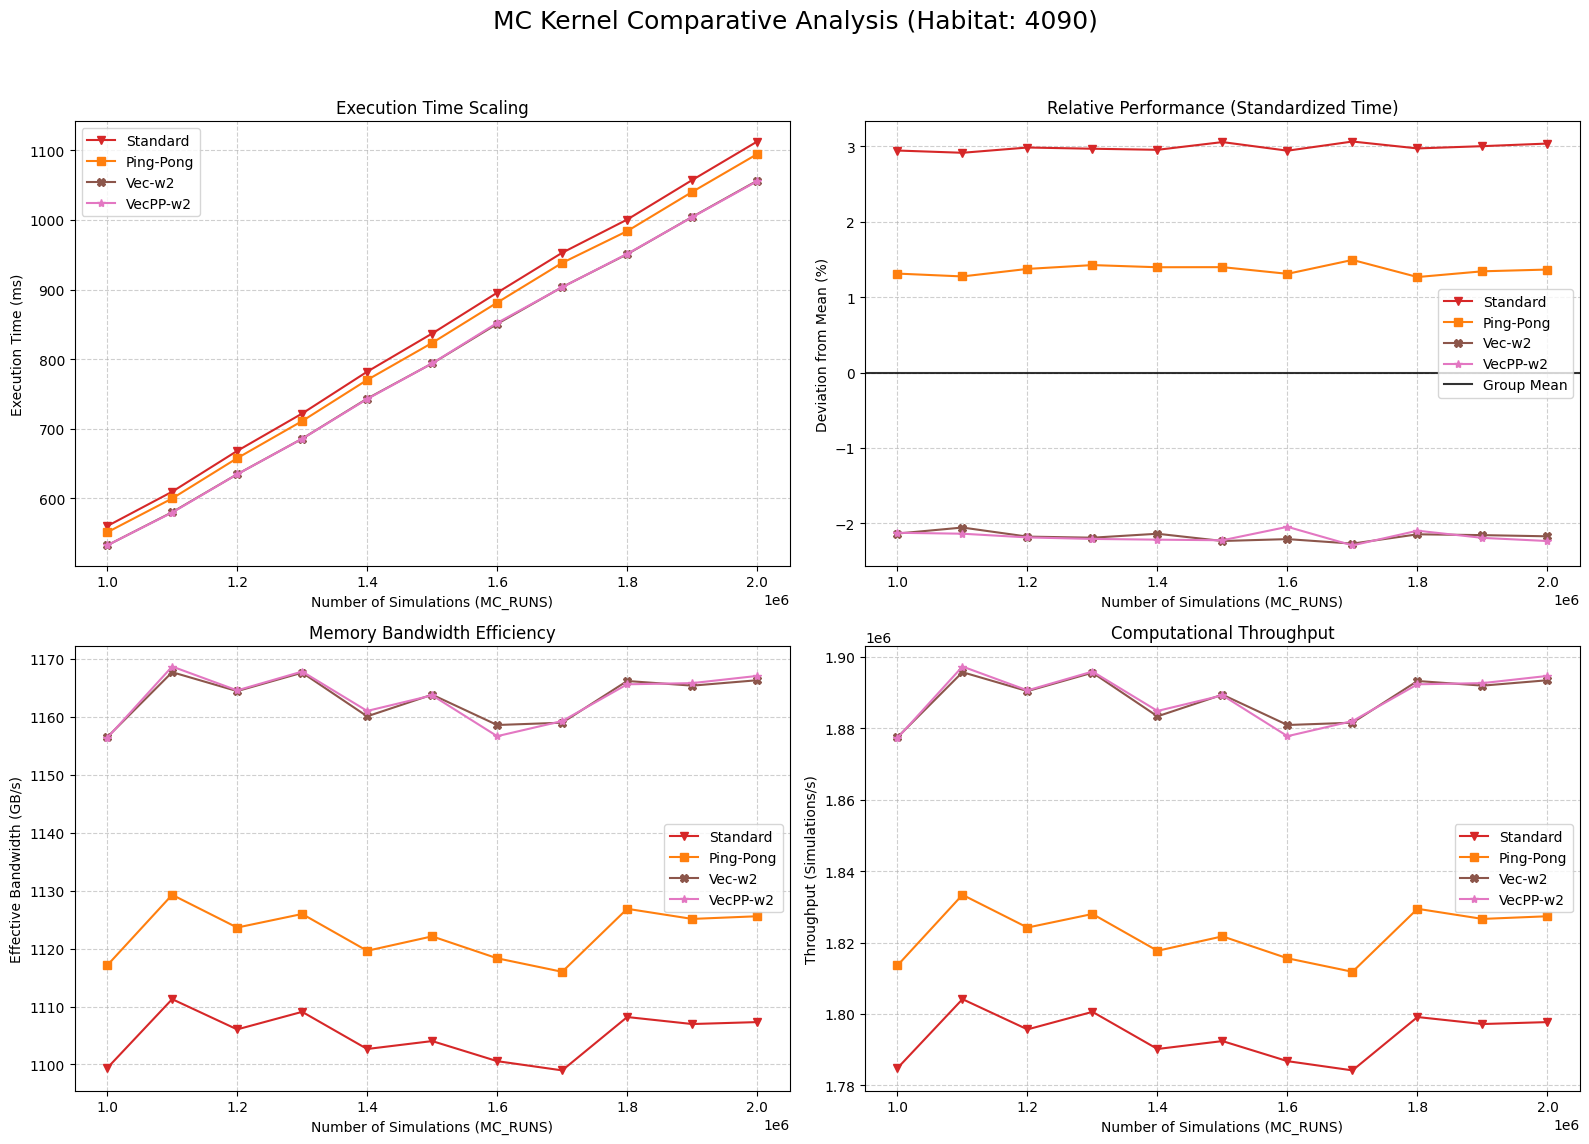

In [5]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
colors = {
    "Standard": "#d62728",
    "Ping-Pong": "#ff7f0e",
    "Vec-w2": "#8c564b",
    "VecPP-w2": "#e377c2"
}
markers = {
    "Standard": "v",
    "Ping-Pong": "s",
    "Vec-w2": "X",
    "VecPP-w2": "*"
}

# Subplot 1: Time Scaling
for k in kernels_to_bench:
    name = k["name"]
    ax1.plot(run_sizes, results_scaling[name], marker=markers[name], label=name, color=colors[name])
ax1.set_xlabel("Number of Simulations (MC_RUNS)")
ax1.set_ylabel("Execution Time (ms)")
ax1.set_title("Execution Time Scaling")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# Subplot 2: Standardized Relative Time (Deviation from Mean)
for k in kernels_to_bench:
    name = k["name"]
    # Standardized Relative Performance calculation
    deviations = []
    for i, runs in enumerate(run_sizes):
        group_mean = np.mean([results_scaling[other["name"]][i] for other in kernels_to_bench])
        val = results_scaling[name][i]
        dev_pct = (val / group_mean - 1.0) * 100.0
        deviations.append(dev_pct)
    ax2.plot(run_sizes, deviations, marker=markers[name], label=name, color=colors[name])
ax2.axhline(0.0, color='black', linestyle='-', alpha=0.8, label='Group Mean')
ax2.set_xlabel("Number of Simulations (MC_RUNS)")
ax2.set_ylabel("Deviation from Mean (%)")
ax2.set_title("Relative Performance (Standardized Time)")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

# Subplot 3: Bandwidth scaling
for k in kernels_to_bench:
    name = k["name"]
    ax3.plot(run_sizes, bandwidths_scaling[name], marker=markers[name], label=name, color=colors[name])
ax3.set_xlabel("Number of Simulations (MC_RUNS)")
ax3.set_ylabel("Effective Bandwidth (GB/s)")
ax3.set_title("Memory Bandwidth Efficiency")
ax3.grid(True, linestyle="--", alpha=0.6)
ax3.legend()

# Subplot 4: Throughput
for k in kernels_to_bench:
    name = k["name"]
    ax4.plot(run_sizes, throughputs_scaling[name], marker=markers[name], label=name, color=colors[name])
ax4.set_xlabel("Number of Simulations (MC_RUNS)")
ax4.set_ylabel("Throughput (Simulations/s)")
ax4.set_title("Computational Throughput")
ax4.grid(True, linestyle="--", alpha=0.6)
ax4.legend()

plt.suptitle(f"MC Kernel Comparative Analysis (Habitat: {target_habitat.habitat_code})", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Vectorization Width Sweep — "how far can we push?"

The vectorized kernel uses MWC64X's vector RNG (`mwc64xvec2/4/8`) to advance `W` independent lanes per `Step()`. Vectorizing the inner step is the win; the catch is that our launch-independent seeding builds the vector state from `W` scalar seeds, so the per-run seeding cost grows ~`W`x. There is no `vec16`, so **W = 8 is the hard ceiling**. This sweep compares the scalar baseline (W=1) against W in {2, 4, 8} to locate where the stepping gain is overtaken by seeding / occupancy cost. Both vectorized reductions (in-place **tree** and **ping-pong**) are swept so their width behaviour can be compared directly.

,Variant,Width,Time (ms),Speedup
0,scalar,1,5616.75,1.00x
1,vec tree,2,5333.24,1.05x
2,vec tree,4,6022.25,0.93x
3,vec tree,8,7822.44,0.72x
4,vec ping-pong,2,5345.82,1.05x
5,vec ping-pong,4,6006.56,0.94x
6,vec ping-pong,8,7840.97,0.72x


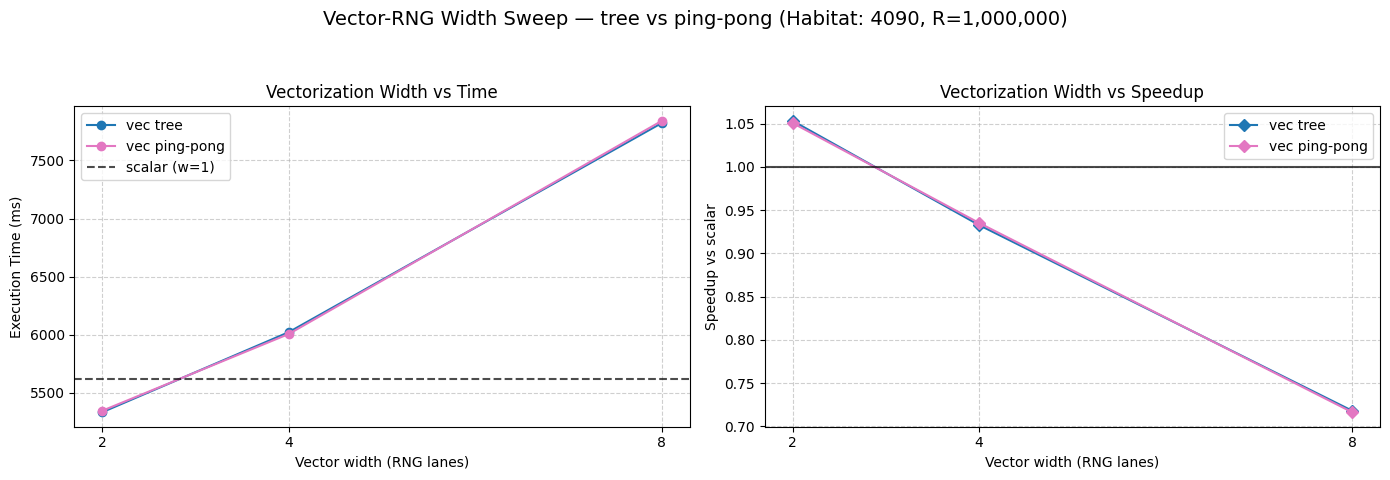

In [6]:
# Reuses target_habitat, MC_RUNS, THRESHOLD, SEED, N_BATCHES,
# n_wg_target and _canonical_topology defined in the Phase 1 cell.
# Compares the two vectorized reductions (tree vs ping-pong) across widths
# against the scalar baseline (w=1).
sweep_widths = [2, 4, 8]
vec_variants = {
    "vec tree":      PyOpenCLMonteCarloVectorizedAdapter,
    "vec ping-pong": PyOpenCLMonteCarloVectorizedPingPongAdapter,
}

def _time_ms(adapter):
    cfg = MonteCarloConfig(n_runs=MC_RUNS, threshold=THRESHOLD, seed=SEED,
                           topology=_canonical_topology(adapter, n_wg_target))
    adapter.reset_profile()
    adapter.run(target_habitat, cfg)
    return adapter.benchmark()[0].mean_ms * N_BATCHES

base_t = _time_ms(PyOpenCLMonteCarloAdapter(profiling=True))  # scalar baseline (w=1)
sweep_rows = [{"Variant": "scalar", "Width": 1, "Time (ms)": base_t, "Speedup": 1.0}]
for name, cls in vec_variants.items():
    for w in sweep_widths:
        t = _time_ms(cls(profiling=True, vec_width=w))
        sweep_rows.append({"Variant": name, "Width": w, "Time (ms)": t,
                           "Speedup": base_t / t})

df_sweep = pd.DataFrame(sweep_rows)
display(df_sweep.style.format({"Time (ms)": "{:.2f}", "Speedup": "{:.2f}x"}))

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))
for name, color in [("vec tree", "#1f77b4"), ("vec ping-pong", "#e377c2")]:
    sub = df_sweep[df_sweep["Variant"] == name]
    axA.plot(sub["Width"], sub["Time (ms)"], marker="o", label=name, color=color)
    axB.plot(sub["Width"], sub["Speedup"], marker="D", label=name, color=color)
axA.axhline(base_t, color="black", linestyle="--", alpha=0.7, label="scalar (w=1)")
axA.set_xlabel("Vector width (RNG lanes)"); axA.set_ylabel("Execution Time (ms)")
axA.set_title("Vectorization Width vs Time"); axA.set_xticks(sweep_widths)
axA.grid(True, linestyle="--", alpha=0.6); axA.legend()
axB.axhline(1.0, color="black", linestyle="-", alpha=0.7)
axB.set_xlabel("Vector width (RNG lanes)"); axB.set_ylabel("Speedup vs scalar")
axB.set_title("Vectorization Width vs Speedup"); axB.set_xticks(sweep_widths)
axB.grid(True, linestyle="--", alpha=0.6); axB.legend()
plt.suptitle(f"Vector-RNG Width Sweep — tree vs ping-pong (Habitat: {target_habitat.habitat_code}, R={MC_RUNS:,})", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.93]); plt.show()

## Phase 3: Decoupled LWS and GWS Parameter Tuning Analysis

Following our optimizations to parameterize work-group sizes dynamically, the GPU parameter tuning sweep was executed using the standalone Python script `benchmark/benchmark_lws_gws.py`. The execution, profiling, and hardware telemetry have been decoupled from this notebook. The results were exported into the structured data file `benchmark/lws_gws_benchmark.csv`.

We now load the benchmark CSV data and plot the **Computational Throughput** and **Relative Performance (Deviation from Group Mean %)** to analyze work-group scaling behavior.

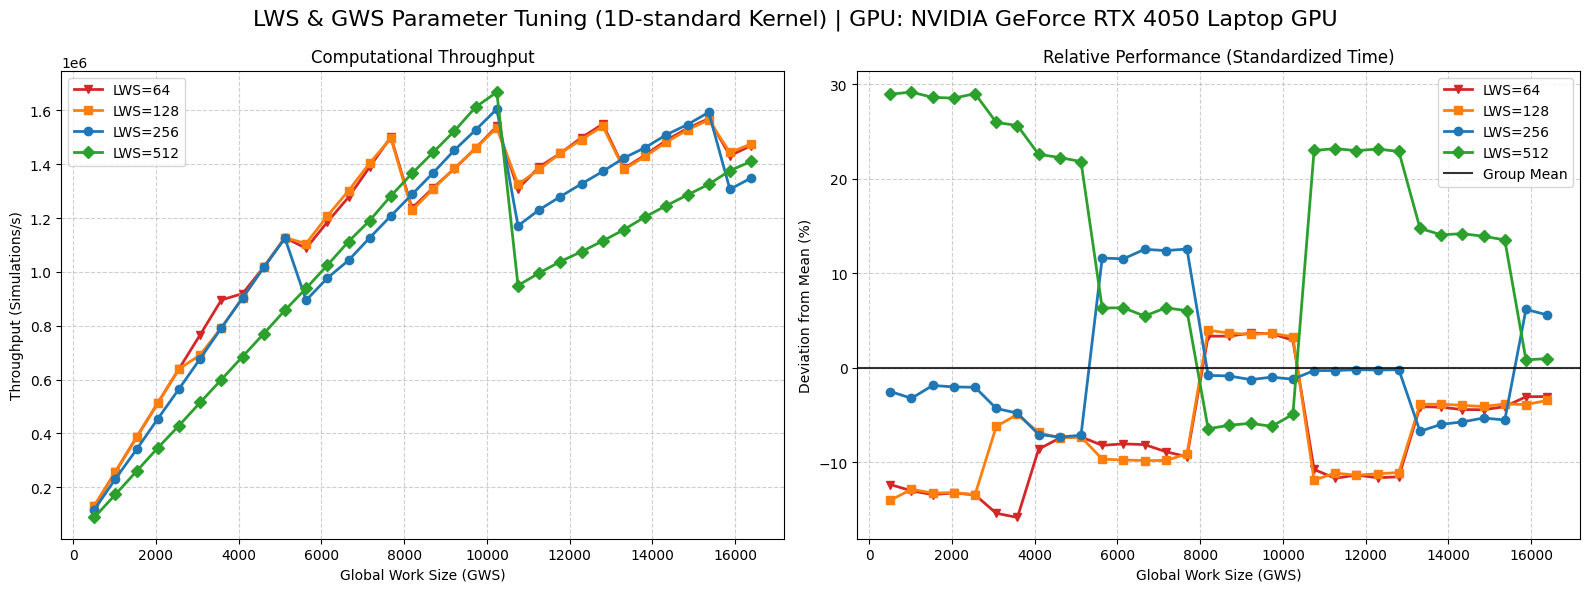

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load the benchmark CSV generated by benchmark_lws_gws.py
csv_path = Path("lws_gws_benchmark.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Benchmark data not found at '{csv_path}'. Please run the python sweep script first!")

df_bench = pd.read_csv(csv_path)
gpu_name = df_bench["GPU"].iloc[0] if "GPU" in df_bench.columns else "Unknown GPU"
kernel_label = df_bench["Kernel"].iloc[0] if "Kernel" in df_bench.columns else "Standard"

lws_options = sorted(df_bench["LWS"].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors_lws = {
    64:  "#d62728",
    128: "#ff7f0e",
    256: "#1f77b4",
    512: "#2ca02c"
}
markers_lws = {
    64:  "v",
    128: "s",
    256: "o",
    512: "D"
}

for lws in lws_options:
    sub_df = df_bench[df_bench["LWS"] == lws].sort_values("GWS")
    
    # Plot Throughput
    ax1.plot(
        sub_df["GWS"],
        sub_df["Throughput (Sim/s)"],
        marker=markers_lws[lws],
        label=f"LWS={lws}",
        color=colors_lws[lws],
        linewidth=2
    )
    
    # Plot Standardized Relative Time (Deviation from Mean %)
    ax2.plot(
        sub_df["GWS"],
        sub_df["Deviation from Mean (%)"],
        marker=markers_lws[lws],
        label=f"LWS={lws}",
        color=colors_lws[lws],
        linewidth=2
    )

# Subplot 1: Throughput
ax1.set_xlabel("Global Work Size (GWS)")
ax1.set_ylabel("Throughput (Simulations/s)")
ax1.set_title("Computational Throughput")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# Subplot 2: Standardized Relative Performance
ax2.axhline(0.0, color='black', linestyle='-', alpha=0.8, label='Group Mean')
ax2.set_xlabel("Global Work Size (GWS)")
ax2.set_ylabel("Deviation from Mean (%)")
ax2.set_title("Relative Performance (Standardized Time)")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

plt.suptitle(f"LWS & GWS Parameter Tuning ({kernel_label} Kernel) | GPU: {gpu_name}", fontsize=16)
plt.tight_layout()
plt.show()

## Statistical Robustness: Scalar vs. Vectorized Kernels

The plot below visualises the **two-proportion Z-test** for each vectorized
kernel against the scalar baseline.

- The **grey curve** is the $\mathcal{N}(0,1)$ null distribution.
- The **red shaded regions** are the rejection zones $|z| > z_{\alpha/2}$.
- The **dashed red lines** mark $\pm z_{\alpha/2}$ (critical values).
- Each **solid coloured vertical line** is the observed $z$-statistic for one kernel.
- The **translucent shaded area** beyond each observed $z$ toward the tail
  represents the contribution to the $p$-value (two-tailed).

Data are loaded from `benchmark/statistical_robustness.csv`
(generated by `benchmark/statistical_robustness.py`).

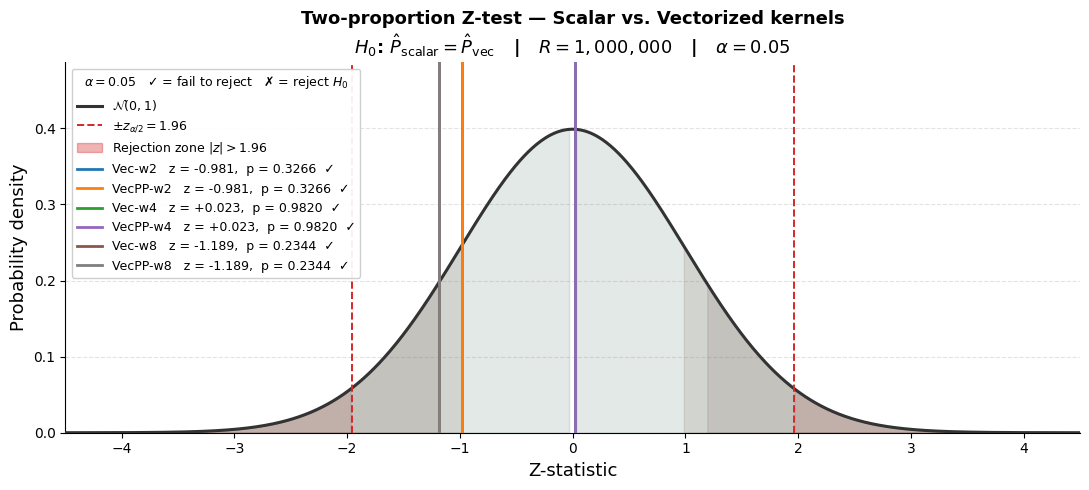

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.stats import norm

# ── Load data ──────────────────────────────────────────────────────────────
csv_path = Path("statistical_robustness.csv")
if not csv_path.exists():
    raise FileNotFoundError(
        f"'{csv_path}' not found. Run:\n"
        "  python benchmark/statistical_robustness.py"
    )

df = pd.read_csv(csv_path)
ALPHA  = float(df["alpha"].iloc[0])
R      = int(df["R"].iloc[0])
z_crit = norm.ppf(1 - ALPHA / 2)   # 1.96 for α = 0.05

# Kernel display order & colour palette
KERNEL_ORDER = ["Vec-w2", "VecPP-w2", "Vec-w4", "VecPP-w4", "Vec-w8", "VecPP-w8"]
KERNEL_ORDER = [k for k in KERNEL_ORDER if k in df["kernel_vec"].values]
palette   = plt.cm.tab10(np.linspace(0, 0.7, len(KERNEL_ORDER)))
color_map = dict(zip(KERNEL_ORDER, palette))

# ── Figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

# N(0,1) curve
x = np.linspace(-4.5, 4.5, 1_000)
ax.plot(x, norm.pdf(x), color="#333333", lw=2.2, zorder=3,
        label=r"$\mathcal{N}(0,1)$")

# Red rejection regions
for x_rej in [x[x >= z_crit], x[x <= -z_crit]]:
    ax.fill_between(x_rej, norm.pdf(x_rej),
                    alpha=0.15, color="#d62728", zorder=1)

# Dashed critical-value lines
ax.axvline( z_crit, color="#d62728", lw=1.4, linestyle="--", zorder=4,
            label=f"$\\pm z_{{\\alpha/2}} = {z_crit:.2f}$")
ax.axvline(-z_crit, color="#d62728", lw=1.4, linestyle="--", zorder=4)

# One vertical line per kernel + tail shading for the p-value area
for kernel in KERNEL_ORDER:
    row      = df[df["kernel_vec"] == kernel].iloc[0]
    z_obs    = float(row["z_stat"])
    p_val    = float(row["p_value_ztest"])
    rejected = bool(row["reject_H0_ztest"])

    if np.isnan(z_obs):
        continue

    col   = color_map[kernel]
    label = (f"{kernel}   z = {z_obs:+.3f},  p = {p_val:.4f}"
             + ("  ✗" if rejected else "  ✓"))

    # Solid vertical line at the observed statistic
    ax.axvline(z_obs, color=col, lw=2.0, linestyle="-", zorder=5, label=label)

    # Translucent tail shading (both sides) = p-value area
    abs_z = abs(z_obs)
    for sign in [+1, -1]:
        x_tail = x[(sign * x) >= abs_z]
        if len(x_tail):
            ax.fill_between(x_tail, norm.pdf(x_tail),
                            color=col, alpha=0.09, zorder=2)

# ── Formatting ─────────────────────────────────────────────────────────────
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(0, norm.pdf(0) * 1.22)
ax.set_xlabel("Z-statistic", fontsize=13)
ax.set_ylabel("Probability density", fontsize=13)
ax.set_title(
    "Two-proportion Z-test — Scalar vs. Vectorized kernels\n"
    rf"$H_0$: $\hat{{P}}_{{\mathrm{{scalar}}}} = \hat{{P}}_{{\mathrm{{vec}}}}$"
    f"   |   $R = {R:,}$   |   $\\alpha = {ALPHA}$",
    fontsize=13, fontweight="bold",
)

# Rejection patch for legend
rej_patch = mpatches.Patch(color="#d62728", alpha=0.35,
                           label=f"Rejection zone $|z| > {z_crit:.2f}$")
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=[handles[0], handles[1], rej_patch] + handles[2:],
    labels =[labels[0],  labels[1],  rej_patch.get_label()] + labels[2:],
    fontsize=9, loc="upper left",
    framealpha=0.93, edgecolor="#cccccc",
    title=f"$\\alpha = {ALPHA}$   ✓ = fail to reject   ✗ = reject $H_0$",
    title_fontsize=9,
)

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Phase 4: All-Habitats Time — Habitat-Centric vs Map-Centric

The plots above are for a single habitat. Here we compare the **total execution time across all habitats** (the full pipeline workload) and add the new **Map-Centric** bitmask kernel.

- **Habitat-Centric** (Standard / Ping-Pong 1-D): one kernel launch per habitat; total time is the sum over all habitats.
- **Map-Centric**: a single batched sweep (`run_map`) that processes all habitats at once — one RNG draw per map cell updates every habitat present in that cell via a 64-bit bitmask. It runs over the **union footprint** of the habitats (the efficient form; sweeping the full 5.24 M-cell grid of mostly-empty cells would be pointless).

> **Important — in this dataset the habitats do *not* overlap.** The 5 real habitats are spatially disjoint (sum of cells = union footprint = 720,595 → **overlap 1.00×**). The Map-Centric advantage comes *only* from reusing one RNG draw across overlapping habitats, so with zero overlap it issues exactly as many draws as Habitat-Centric while adding the per-cell inner loop over habitats and the 64-wide private accumulators — hence it is **expected to be slower here** (~2.4× at R = 1 M). The destruction probabilities match the baseline, confirming correctness; the paradigm only pays off on heavily-overlapping habitat sets.

Two figures, each reproducing the **top row** of the analysis above (absolute time + standardized *deviation from mean*): one **vs Ping-Pong 1-D**, one **vs the Map-Centric kernel**.

In [9]:
# ── Phase 4: all-habitats time — Habitat-Centric vs Map-Centric ──
import time

from pyroclast import InvasionCriteria, PyOpenCLMapCentricAdapter, SpatialHabitat

# The compacted habitats no longer carry spatial layout, so we rebuild the
# Map-Centric inputs from the *raw, co-registered* rasters. Map-Centric runs
# over the union footprint of all habitats (sweeping the full mostly-empty
# 5.24M-cell grid would be pointless), expressed as a single (1, L) row.
invasion = repo.get(InvasionCriteria())
p_full = invasion.data.astype(np.float32)
risk = p_full > 0.0

masks = {}
union = np.zeros(p_full.shape, dtype=bool)
for h in repo.matching(HabitatCriteria()):
    m = (h.data > 0) & risk          # habitat ∩ footprint == the compaction cells
    masks[h.code] = m
    union |= m
union_idx = np.flatnonzero(union.ravel())

p_union = np.ascontiguousarray(
    p_full.ravel()[union_idx], dtype=np.float32
).reshape(1, -1)
spatial_habitats = [
    SpatialHabitat(code, masks[code].ravel()[union_idx].reshape(1, -1), THRESHOLD)
    for code in sorted(masks)
]

sum_cells = sum(int(m.sum()) for m in masks.values())
print(
    f"All habitats: {len(spatial_habitats)} | grid = {p_full.shape} "
    f"({p_full.size:,} cells) | union footprint = {union_idx.size:,} cells | "
    f"overlap = {sum_cells / max(1, union_idx.size):.2f}x"
)

# Adapters built once (avoid per-point recompilation).
mc_standard = PyOpenCLMonteCarloAdapter()
mc_pingpong = PyOpenCLMonteCarloPingPongAdapter()
mc_mapcentric = PyOpenCLMapCentricAdapter()


def _time_habitat_centric(adapter, runs):
    """Wall-clock (ms) for the iterative loop over ALL compacted habitats."""
    adapter._queue.finish()
    t0 = time.perf_counter()
    for h in compacted:
        cfg = MonteCarloConfig(
            n_runs=runs, threshold=THRESHOLD, seed=SEED,
            topology=_canonical_topology(adapter, n_wg_target),
        )
        adapter.run(h, cfg)
    adapter._queue.finish()
    return (time.perf_counter() - t0) * 1e3


def _time_map_centric(adapter, runs):
    """Wall-clock (ms) for one batched run_map over all habitats."""
    cfg = MonteCarloConfig(n_runs=runs, threshold=THRESHOLD, seed=SEED)
    adapter._queue.finish()
    t0 = time.perf_counter()
    adapter.run_map(p_union, spatial_habitats, cfg)
    adapter._queue.finish()
    return (time.perf_counter() - t0) * 1e3


P4_RUNS = list(range(1_000_000, 2_000_000 + 1, 100_000))
p4_series = {"Standard": [], "Ping-Pong": [], "Map-Centric": []}

print("Running Phase 4 all-habitats time sweep...")
for runs in P4_RUNS:
    p4_series["Standard"].append(_time_habitat_centric(mc_standard, runs))
    p4_series["Ping-Pong"].append(_time_habitat_centric(mc_pingpong, runs))
    p4_series["Map-Centric"].append(_time_map_centric(mc_mapcentric, runs))
    print(f"  Completed R={runs:,}", end="\r")
print("\nPhase 4 sweep completed.")

All habitats: 5 | grid = (2423, 2164) (5,243,372 cells) | union footprint = 720,595 cells | overlap = 1.00x
Running Phase 4 all-habitats time sweep...
  Completed R=2,000,000
Phase 4 sweep completed.


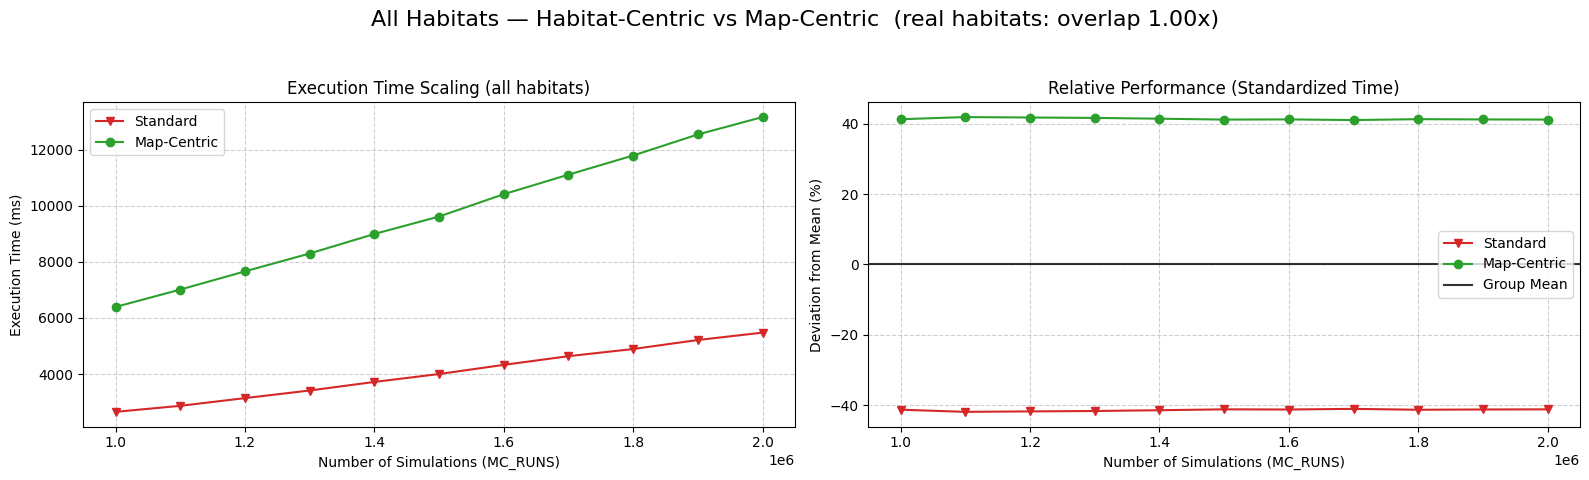

In [10]:
# ── Phase 4 plots: two top-row comparisons (absolute + standardized time) ──
P4_COLORS = {"Standard": "#d62728", "Ping-Pong": "#ff7f0e", "Map-Centric": "#2ca02c"}
P4_MARKERS = {"Standard": "v", "Ping-Pong": "s", "Map-Centric": "o"}


def _plot_time_pair(names, suptitle):
    """Replicate the top row of the analysis (absolute + standardized time)."""
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 5))

    # Left: absolute execution time scaling
    for n in names:
        axL.plot(P4_RUNS, p4_series[n], marker=P4_MARKERS[n],
                 color=P4_COLORS[n], label=n)
    axL.set_xlabel("Number of Simulations (MC_RUNS)")
    axL.set_ylabel("Execution Time (ms)")
    axL.set_title("Execution Time Scaling (all habitats)")
    axL.grid(True, linestyle="--", alpha=0.6)
    axL.legend()

    # Right: standardized relative time (deviation from the group mean, %)
    for n in names:
        dev = []
        for i in range(len(P4_RUNS)):
            group_mean = np.mean([p4_series[m][i] for m in names])
            dev.append((p4_series[n][i] / group_mean - 1.0) * 100.0)
        axR.plot(P4_RUNS, dev, marker=P4_MARKERS[n],
                 color=P4_COLORS[n], label=n)
    axR.axhline(0.0, color="black", linestyle="-", alpha=0.8, label="Group Mean")
    axR.set_xlabel("Number of Simulations (MC_RUNS)")
    axR.set_ylabel("Deviation from Mean (%)")
    axR.set_title("Relative Performance (Standardized Time)")
    axR.grid(True, linestyle="--", alpha=0.6)
    axR.legend()

    plt.suptitle(suptitle, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.94])
    plt.show()

# Figure — vs the new Map-Centric kernel (all habitats)
_plot_time_pair(
    ["Standard", "Map-Centric"],
    "All Habitats — Habitat-Centric vs Map-Centric  (real habitats: overlap 1.00x)",
)

## Phase 5: Synthetic Overlapping Habitats over the Real Map — Ping-Pong 1-D vs Map-Centric

Phase 4 showed the Map-Centric kernel *losing* because the 5 real habitats are spatially **disjoint** (overlap 1.00×): with no shared cells there is no RNG draw to reuse. Here we build the regime the Map-Centric paradigm was designed for — **64 synthetic, heavily-overlapping habitats** laid over the **active region (p>0) of the real probability map** (which is ~57.6 % of the grid).

- **Habitat-Centric (Ping-Pong 1-D)**: 64 kernel launches, one per habitat; each habitat re-samples its own cells, so a shared cell is sampled once *per overlapping habitat* — total work ∝ Σ habitat cells.
- **Map-Centric**: a single `run_map` launch over the **union footprint** `(1, L)`; one RNG draw per map cell updates every habitat present in it via the 64-bit bitmask — total work ∝ union cells.

With overlap > 1 the Habitat-Centric loop does far more RNG work than Map-Centric, so this is where Map-Centric should finally catch up or win. We time both at a single `R = 50 000` and check the destruction probabilities agree (the two paradigms use different RNG streams, so a small `max|Δp|` confirms correctness, not bit-exactness).

In [11]:
# ── Phase 5: 64 synthetic overlapping habitats over the REAL probability map ──
import time

import numpy as np

from pyroclast import (
    InvasionCriteria,
    PyOpenCLMapCentricAdapter,
    PyOpenCLMonteCarloPingPongAdapter,
    SpatialHabitat,
)
from pyroclast.domain.models import CompactedHabitat, MonteCarloConfig

try:
    from benchmark.synthetic_habitat import make_overlapping_habitats_over_map
except ModuleNotFoundError:
    from synthetic_habitat import make_overlapping_habitats_over_map

R5 = 50_000

# Real probability map (reloaded so this cell is independent of Phase 4).
p_full = repo.get(InvasionCriteria()).data.astype(np.float32)
flat = p_full.ravel()

# 64 overlapping habitats confined to the active (p>0) region.
syn = make_overlapping_habitats_over_map(
    p_full, n_habitats=64, seed=SEED, threshold=THRESHOLD
)

# ── Map-Centric inputs: compact to the union footprint as a (1, L) row ──
union = np.zeros(p_full.shape, dtype=bool)
for h in syn:
    union |= h.presence_mask
u_idx = np.flatnonzero(union.ravel())
p_union = np.ascontiguousarray(flat[u_idx], dtype=np.float32).reshape(1, -1)
syn_spatial = [
    SpatialHabitat(h.habitat_code, h.presence_mask.ravel()[u_idx].reshape(1, -1), THRESHOLD)
    for h in syn
]

# ── Habitat-Centric inputs: compact each habitat to its own cells ──
syn_compacted = []
for h in syn:
    idx = np.flatnonzero(h.presence_mask.ravel())
    syn_compacted.append(
        CompactedHabitat(
            habitat_code=h.habitat_code,
            n_cells=int(idx.size),
            p_vec=np.ascontiguousarray(flat[idx], dtype=np.float32),
        )
    )

# Adapters (compiled once).
pp = PyOpenCLMonteCarloPingPongAdapter()
mp = PyOpenCLMapCentricAdapter()

# ── Time Ping-Pong 1-D (64 launches, Habitat-Centric) ──
cfg_hc = MonteCarloConfig(
    n_runs=R5, threshold=THRESHOLD, seed=SEED,
    topology=_canonical_topology(pp, n_wg_target),
)
pp._queue.finish()
t0 = time.perf_counter()
pp_probs = {h.habitat_code: pp.run(h, cfg_hc) for h in syn_compacted}
pp._queue.finish()
t_pp = (time.perf_counter() - t0) * 1e3

# ── Time Map-Centric (1 launch, full 64-bit bitmask) ──
cfg_mc = MonteCarloConfig(n_runs=R5, threshold=THRESHOLD, seed=SEED)
mp._queue.finish()
t0 = time.perf_counter()
mp_probs = mp.run_map(p_union, syn_spatial, cfg_mc)
mp._queue.finish()
t_mc = (time.perf_counter() - t0) * 1e3

max_dp = max(abs(pp_probs[c] - mp_probs[c]) for c in pp_probs)
speedup = t_pp / t_mc if t_mc > 0 else float("nan")
print(
    f"\nR={R5:,}  |  {len(syn)} habitats over {u_idx.size:,} union cells "
    f"({100 * u_idx.size / p_full.size:.1f}% of grid)\n"
    f"  Ping-Pong 1-D (Habitat-Centric)  : {t_pp:8.1f} ms  ({len(syn)} launches)\n"
    f"  Map-Centric  (bitmask)           : {t_mc:8.1f} ms  (1 launch)\n"
    f"  speedup (Ping-Pong / Map-Centric): {speedup:.2f}x\n"
    f"  max|Δp| (correctness)             : {max_dp:.4f}"
)

[habitats_over_map] grid=2423x2164 (5,243,372 cells)  active(p>0)=3,020,039 (57.6%)  n_habitats=64  block=724x647  sum(cells)=24,541,722  union=3,003,726 (57.3% of grid)  overlap≈8.17x  threshold=0.005

R=50,000  |  64 habitats over 3,003,726 union cells (57.3% of grid)
  Ping-Pong 1-D (Habitat-Centric)  :   4545.1 ms  (64 launches)
  Map-Centric  (bitmask)           :   7224.5 ms  (1 launch)
  speedup (Ping-Pong / Map-Centric): 0.63x
  max|Δp| (correctness)             : 0.0000


## Phase 6: 2-D Monte Carlo — parallelising the cell scan

The 1-D kernels serialise the per-run cell scan inside `_count_invaded` (one work-item draws all `n_cells` of a run). The **2-D kernels** add a second grid axis of `cell_lanes` threads that scan the cells cooperatively, then close each run with **two reductions**: first over the cell lanes (→ invaded count, then `> threshold` → a 0/1 *destroyed* flag), then over the `run_lanes` of the work-group (→ one int per work-group; the shared `reduce_sum_int` finishes the global sum).

Two launch grids are compared:

- **array-in-X** (`monte_carlo_2d`): the cell axis is on dim0 (the hardware-fast axis), so consecutive cell lanes read consecutive `p_vec` cells — coalesced loads.
- **transposed** (`monte_carlo_2d_transposed`): the run axis is on dim0, so all run lanes read the *same* `p_vec` address (broadcast) and the cell-axis reduction strides through local memory with a different bank pattern.

The cell axis uses the *interleaved* partition (cell lane `L` handles cells `L, L+Lc, …`), i.e. the same stream layout as the vectorized kernel with `VEC_WIDTH == cell_lanes`. The two 2-D grids are therefore **bit-exact with each other** and agree **statistically** with the scalar 1-D kernel (which uses a different stream layout). The cells below check correctness, then compare the launch grids across `n_runs` and across work-group shapes.

In [12]:
# ── Phase 6: 2-D kernels — setup + correctness ──
from pyroclast import (
    PyOpenCLMonteCarlo2DAdapter,
    PyOpenCLMonteCarlo2DTransposedAdapter,
)

mc_1d   = PyOpenCLMonteCarloAdapter(profiling=True)
mc_2d   = PyOpenCLMonteCarlo2DAdapter(profiling=True)            # cell_lanes=64, run_lanes=4
mc_2d_t = PyOpenCLMonteCarlo2DTransposedAdapter(profiling=True)  # same shape, transposed grid

# 1-D uses the canonical topology; the 2-D adapters use their own 2-D default.
cfg_1d = MonteCarloConfig(n_runs=MC_RUNS, threshold=THRESHOLD, seed=SEED,
                          topology=_canonical_topology(mc_1d, n_wg_target))
cfg_2d = MonteCarloConfig(n_runs=MC_RUNS, threshold=THRESHOLD, seed=SEED)

p_1d   = mc_1d.run(target_habitat, cfg_1d)
p_2d   = mc_2d.run(target_habitat, cfg_2d)
p_2d_t = mc_2d_t.run(target_habitat, cfg_2d)

print(f"Habitat {target_habitat.habitat_code}  |  R={MC_RUNS:,}  theta={THRESHOLD}")
print(f"  Standard 1-D      : p = {p_1d:.5f}")
print(f"  2-D (array-in-X)  : p = {p_2d:.5f}")
print(f"  2-D (transposed)  : p = {p_2d_t:.5f}")
print(f"  |p_2d - p_2d_t|   = {abs(p_2d - p_2d_t):.6f}   (expected 0.0 — the two grids are bit-exact)")
print(f"  max|Δp| vs 1-D    = {max(abs(p_2d - p_1d), abs(p_2d_t - p_1d)):.5f}   (Monte Carlo error — different stream)")

Habitat 4090  |  R=1,000,000  theta=0.005
  Standard 1-D      : p = 0.00000
  2-D (array-in-X)  : p = 0.00000
  2-D (transposed)  : p = 0.00000
  |p_2d - p_2d_t|   = 0.000000   (expected 0.0 — the two grids are bit-exact)
  max|Δp| vs 1-D    = 0.00000   (Monte Carlo error — different stream)


Running Phase 6 layout scaling sweep...
  Completed R=2,000,000
Phase 6 layout sweep completed.


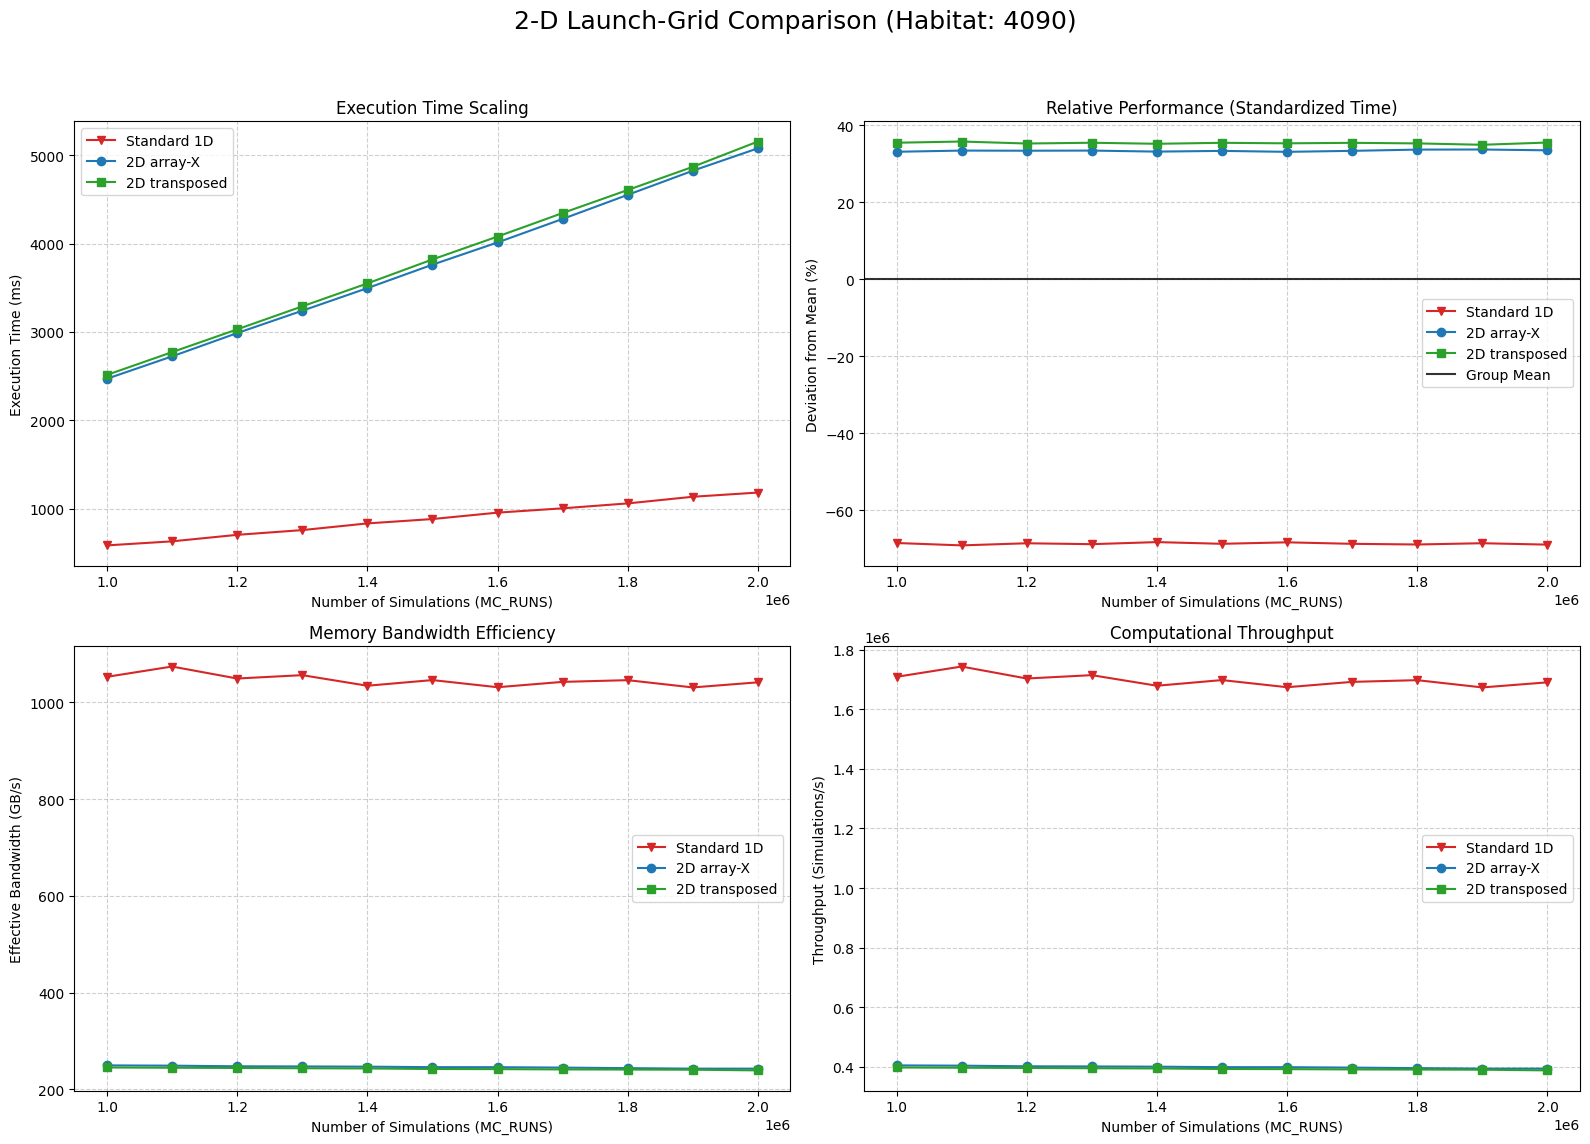

In [13]:
# ── Phase 6: layout scaling sweep — Standard 1-D vs 2-D vs 2-D transposed ──
# 1-D uses the canonical topology; the 2-D adapters use their own 2-D default.
# Topologies are fixed across the sweep (only n_runs varies), mirroring Phase 2.
p6_kernels = [
    {"name": "Standard 1D",   "adapter": mc_1d,   "topo": _canonical_topology(mc_1d, n_wg_target)},
    {"name": "2D array-X",    "adapter": mc_2d,   "topo": mc_2d.suggest_topology(MC_RUNS)},
    {"name": "2D transposed", "adapter": mc_2d_t, "topo": mc_2d_t.suggest_topology(MC_RUNS)},
]
p6_names = [k["name"] for k in p6_kernels]
p6_time = {n: [] for n in p6_names}
p6_bw   = {n: [] for n in p6_names}
p6_tput = {n: [] for n in p6_names}

print("Running Phase 6 layout scaling sweep...")
for runs in run_sizes:
    for k in p6_kernels:
        a = k["adapter"]
        cfg = MonteCarloConfig(n_runs=runs, threshold=THRESHOLD, seed=SEED, topology=k["topo"])
        a.reset_profile()
        a.run_batched(target_habitat, cfg, N_BATCHES_SCALING)
        b = a.benchmark()[0]
        t = b.mean_ms * N_BATCHES_SCALING
        p6_time[k["name"]].append(t)
        p6_bw[k["name"]].append(b.bandwidth_gbs)
        p6_tput[k["name"]].append(runs / (t / 1000.0))
    print(f"  Completed R={runs:,}", end="\r")
print("\nPhase 6 layout sweep completed.")

p6_colors  = {"Standard 1D": "#d62728", "2D array-X": "#1f77b4", "2D transposed": "#2ca02c"}
p6_markers = {"Standard 1D": "v",        "2D array-X": "o",        "2D transposed": "s"}

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
for n in p6_names:
    ax1.plot(run_sizes, p6_time[n], marker=p6_markers[n], color=p6_colors[n], label=n)
ax1.set_xlabel("Number of Simulations (MC_RUNS)"); ax1.set_ylabel("Execution Time (ms)")
ax1.set_title("Execution Time Scaling"); ax1.grid(True, linestyle="--", alpha=0.6); ax1.legend()

for n in p6_names:
    dev = []
    for i in range(len(run_sizes)):
        gm = np.mean([p6_time[m][i] for m in p6_names])
        dev.append((p6_time[n][i] / gm - 1.0) * 100.0)
    ax2.plot(run_sizes, dev, marker=p6_markers[n], color=p6_colors[n], label=n)
ax2.axhline(0.0, color="black", linestyle="-", alpha=0.8, label="Group Mean")
ax2.set_xlabel("Number of Simulations (MC_RUNS)"); ax2.set_ylabel("Deviation from Mean (%)")
ax2.set_title("Relative Performance (Standardized Time)"); ax2.grid(True, linestyle="--", alpha=0.6); ax2.legend()

for n in p6_names:
    ax3.plot(run_sizes, p6_bw[n], marker=p6_markers[n], color=p6_colors[n], label=n)
ax3.set_xlabel("Number of Simulations (MC_RUNS)"); ax3.set_ylabel("Effective Bandwidth (GB/s)")
ax3.set_title("Memory Bandwidth Efficiency"); ax3.grid(True, linestyle="--", alpha=0.6); ax3.legend()

for n in p6_names:
    ax4.plot(run_sizes, p6_tput[n], marker=p6_markers[n], color=p6_colors[n], label=n)
ax4.set_xlabel("Number of Simulations (MC_RUNS)"); ax4.set_ylabel("Throughput (Simulations/s)")
ax4.set_title("Computational Throughput"); ax4.grid(True, linestyle="--", alpha=0.6); ax4.legend()

plt.suptitle(f"2-D Launch-Grid Comparison (Habitat: {target_habitat.habitat_code})", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

Running Phase 6 work-group shape sweep...
Phase 6 shape sweep completed.


Variant,2D array-X,2D transposed
Shape (Lc×Rr),,
32×8,15879.03,16167.74
64×4,25080.25,25143.34
128×2,42239.35,42818.62
256×1,77275.83,77282.59


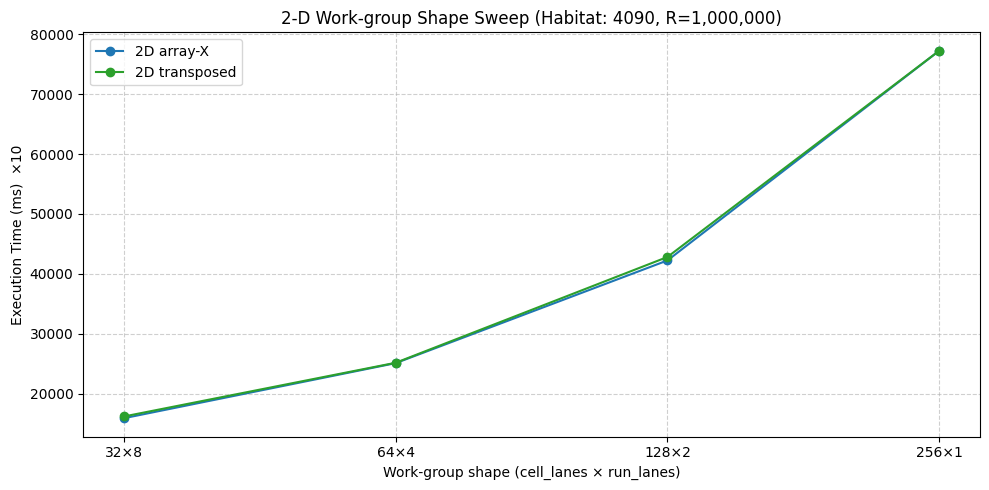

In [14]:
# ── Phase 6: work-group shape sweep for the 2-D kernels ──
# Vary (cell_lanes, run_lanes) at a fixed product (256 work-items/group) to see
# how the cell/run split and the launch-grid orientation affect time. Each shape
# uses the adapter's own 2-D suggest_topology (topology=None).
p6_shapes = [(32, 8), (64, 4), (128, 2), (256, 1)]
p6_shape_variants = {
    "2D array-X":    PyOpenCLMonteCarlo2DAdapter,
    "2D transposed": PyOpenCLMonteCarlo2DTransposedAdapter,
}

shape_rows = []
print("Running Phase 6 work-group shape sweep...")
for (lc, rr) in p6_shapes:
    for label, cls in p6_shape_variants.items():
        a = cls(profiling=True, cell_lanes=lc, run_lanes=rr)
        cfg = MonteCarloConfig(n_runs=MC_RUNS, threshold=THRESHOLD, seed=SEED)
        a.reset_profile()
        a.run(target_habitat, cfg)
        t = a.benchmark()[0].mean_ms * N_BATCHES
        shape_rows.append({
            "Variant": label, "Shape (Lc×Rr)": f"{lc}×{rr}", "Time (ms)": t,
        })
print("Phase 6 shape sweep completed.")

df_shapes = pd.DataFrame(shape_rows)
shape_labels = [f"{lc}×{rr}" for (lc, rr) in p6_shapes]
display(
    df_shapes.pivot(index="Shape (Lc×Rr)", columns="Variant", values="Time (ms)")
    .loc[shape_labels]
    .style.format("{:.2f}")
)

fig, ax = plt.subplots(figsize=(10, 5))
for label, color in [("2D array-X", "#1f77b4"), ("2D transposed", "#2ca02c")]:
    sub = (
        df_shapes[df_shapes["Variant"] == label]
        .set_index("Shape (Lc×Rr)")
        .loc[shape_labels]
    )
    ax.plot(shape_labels, sub["Time (ms)"], marker="o", color=color, label=label)
ax.set_xlabel("Work-group shape (cell_lanes × run_lanes)")
ax.set_ylabel(f"Execution Time (ms)  ×{N_BATCHES}")
ax.set_title(
    f"2-D Work-group Shape Sweep (Habitat: {target_habitat.habitat_code}, R={MC_RUNS:,})"
)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()